### MODEL TRAINING


In [ ]:
import slideflow as sf

# # Load a project and dataset
project = sf.load_project('/home/stanna/PROJECTS/Exp2_Demo')
dataset = project.dataset()

In [ ]:
dataset.summary()

In [ ]:
EXPORT_DIR = "/home/stanna/DATA/Exp2/seg_export"
#my multiclass labels (match the csvs)
labels = ['Benign', 'Dysplasia', 'Invasive carcinoma']

In [21]:
from slideflow import segment

#exporting thumbnails and masks (more computationally efficient)
segment.export_thumbs_and_masks(
    dataset,
    mpp=20,
    dest=EXPORT_DIR,
    mode='multiclass',
    labels=labels
)

Generating data for 10 slides (mode='multiclass', overwrite=False).
Labels: ['Benign', 'Dysplasia', 'Invasive carcinoma']
Skipping slides with no ROIs.


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Exported data for 10 slides.


In [29]:
PROJECT_PATH = "/home/stanna/PROJECTS/Exp2_Demo"
EXPORT_DIR = "/home/stanna/DATA/Exp2/seg_export"
RUN_DIR = "/home/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v1"

project = sf.load_project(PROJECT_PATH)
dataset = project.dataset()

labels = ['Benign', 'Dysplasia', 'Invasive carcinoma']

os.makedirs(RUN_DIR, exist_ok=True)

#create config object
config = segment.SegmentConfig(
    mpp=20,
    size=1024,
    mode="multiclass",
    labels=labels,
    arch="Unet",
    encoder_name="resnet34",
    train_batch_size=2,
    epochs=30,
    lr=1e-4,
)

In [30]:
#use config and dataset object to train model! 

history = segment.train(
    config=config,
    dataset=dataset,
    data_source=EXPORT_DIR,   # <--- USE EXPORTED THUMBS/MASKS
    dest=RUN_DIR,
)

Using 10 slides with non-empty ROIs.
Training from pre-generated thumbnails and masks.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Unet     │ 24.4 M │ train │     0 │
│ 1 │ loss_fn │ DiceLoss │      0 │ train │     0 │
└───┴─────────┴──────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 189                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/segment/data.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output = torch.load(self.paths[index

Saved model to /home/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v1/model.pth


In [60]:
#now we can load the model 
from slideflow import segment
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = "/home/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v1/model.pth"
SLIDE_PATH = "/home/stanna/DATA/Exp2/slides/AH141F.svs"  # or any of your 10

model, trained_config = segment.load_model_and_config(MODEL_PATH)


In [ ]:
# and now use the loaded model! 

# Run whole-slide inference at the config's mpp
pred = model.run_slide_inference(SLIDE_PATH)
print(pred.shape)

#get back an array of pixel-level predictions! 
#Think of it as channels (your classes + background, height, and width)
#argmax takes the class with the highest probability for each pixel 
#so you get a (H, W) array of class IDs! 

[00:24:41] INFO     No ROI for AH141F, using whole slide.

(4, 912, 1024)


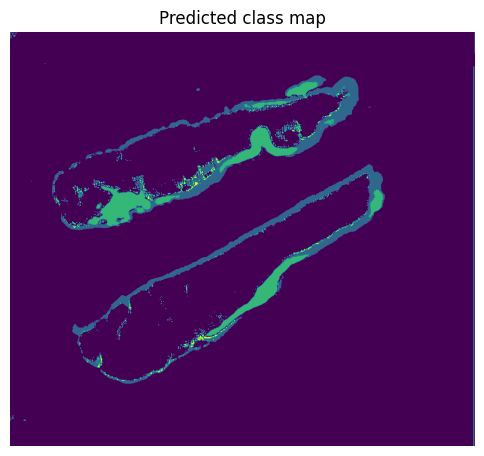

In [34]:
pred_np = pred  # already numpy
label_map = np.argmax(pred_np, axis=0)  # (H, W)

plt.figure(figsize=(6, 6))
plt.imshow(label_map)
plt.axis("off")
plt.title("Predicted class map")
plt.show()

### GENERATE ROIS

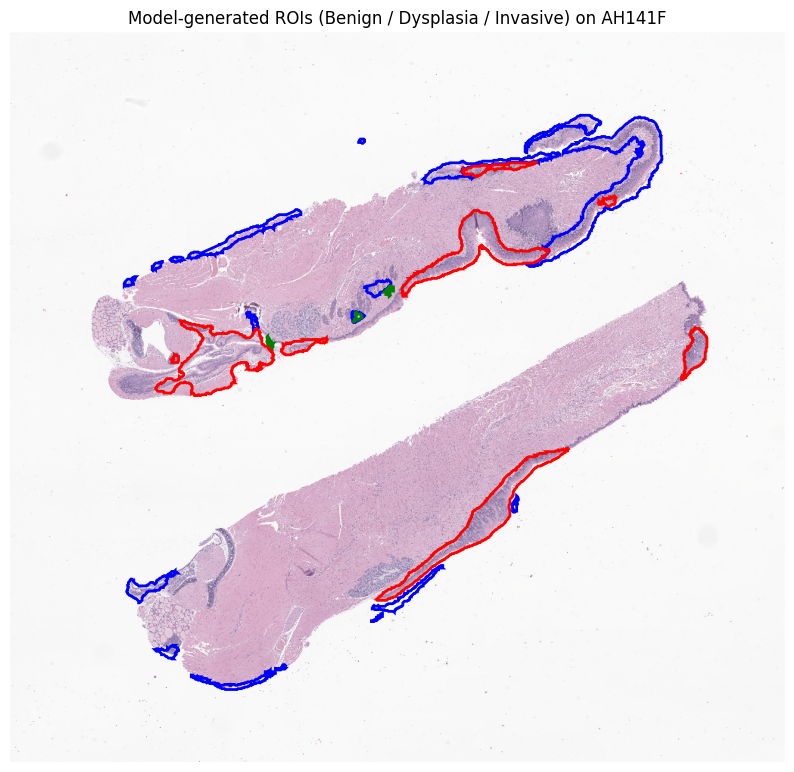

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

# --- Thumbnail (no ROIs drawn yet) ---
thumb_pred = wsi_pred.thumb(width=1024, rois=False)

# Scale from full-res slide → thumbnail
orig_width, _ = wsi_pred.dimensions   # (width, height)
scale = thumb_pred.width / orig_width

# Color map for your 3 classes
color_map = {
    "benign": "blue",
    "dysplasia": "red",
    "invasive carcinoma": "green",
}

def overlay_rois(ax, wsi_obj, scale):
    for roi in wsi_obj.rois:
        geom = roi.poly

        if geom.geom_type == "Polygon":
            polygons = [geom]
        elif geom.geom_type == "MultiPolygon":
            polygons = list(geom.geoms)
        elif geom.geom_type == "GeometryCollection":
            # Keep only the polygonal parts
            polygons = [g for g in geom.geoms if g.geom_type == "Polygon"]
            if not polygons:
                # nothing polygonal to draw
                continue
        else:
            print(f"Unknown geometry type: {geom.geom_type} for ROI with label {roi.label}")
            continue

        raw_label = roi.label
        label = str(raw_label).lower() if raw_label is not None else "unknown"

        color_map = {
            "benign": "blue",
            "dysplasia": "red",
            "invasive carcinoma": "green",
        }
        color = color_map.get(label, "magenta")

        for poly in polygons:
            coords = np.array(poly.exterior.coords) * scale
            patch = MplPolygon(
                coords,
                closed=True,
                edgecolor=color,
                fill=False,
                linewidth=2,
            )
            ax.add_patch(patch)


# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(thumb_pred)
overlay_rois(ax, wsi_pred, scale)
ax.axis("off")
plt.title("Model-generated ROIs (Benign / Dysplasia / Invasive) on AH141F")
plt.show()
